In [1]:
import xarray as xr
import numpy as np
import geopandas as gpd
import regionmask

### before NN interpolating ERA5

In [2]:
era5_2019 = xr.open_dataset('era5_2019.nc') # ERA5 before NN interpolating
print(era5_2019) # view structure
print(abs(era5_2019["fdir"].latitude[1] - era5_2019["fdir"].latitude[0]).values)  # view resolution of ERA5 fdir --- 0.25

<xarray.Dataset> Size: 5MB
Dimensions:     (valid_time: 744, latitude: 39, longitude: 42)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 2019-08-01 ... 2019-08-31T23:...
  * latitude    (latitude) float64 312B 42.0 41.75 41.5 ... 33.0 32.75 32.5
  * longitude   (longitude) float64 336B -124.5 -124.2 -124.0 ... -114.5 -114.2
    number      int64 8B ...
    expver      (valid_time) <U4 12kB ...
Data variables:
    fdir        (valid_time, latitude, longitude) float32 5MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-01-28T02:38 GRIB to CDM+CF via cfgrib-0.9.1...
0.25


### after NN interpolating ERA5

In [3]:
era5_fdir_nn_2019 = xr.open_dataset('era5_fdir_nn_2019.nc') # ERA5 after NN interpolating
era5_fdir_nn_2019 = era5_fdir_nn_2019.rename({"time": "valid_time"})
print(era5_fdir_nn_2019) # view structure
print(abs(era5_fdir_nn_2019["fdir"].latitude[1] - era5_fdir_nn_2019["fdir"].latitude[0]).values)  # view resolution of ERA5 fdir: 0.1

<xarray.Dataset> Size: 30MB
Dimensions:     (valid_time: 744, latitude: 96, longitude: 105)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 2019-08-01 ... 2019-08-31T23:...
  * latitude    (latitude) float64 768B 42.0 41.9 41.8 41.7 ... 32.7 32.6 32.5
  * longitude   (longitude) float64 840B -124.5 -124.4 -124.3 ... -114.2 -114.1
Data variables:
    fdir        (valid_time, latitude, longitude) float32 30MB ...
Attributes:
    source:         ERA5
    target_grid:    era5land_d2m_2019-08-01T00.tif
    interpolation:  Nearest-neighbor in lon/lat space (Spangler-style)
    crs:            EPSG:4326
0.10000000000000142


### convert ERA5 fdir from J/m2 to W/m2

In [4]:
fdir_W = era5_fdir_nn_2019["fdir"] / 3600       # dividy by 3600 seconds since hourly accumulated
fdir_W.attrs["long_name"] = "Total sky direct solar radiation at surface"
fdir_W.attrs["units"] = "W m**-2"

In [5]:
print(fdir_W.attrs)

{'long_name': 'Total sky direct solar radiation at surface', 'units': 'W m**-2'}


### load ERA5-Land

In [6]:
era5land = xr.open_dataset('era5-land_2019.nc') # open ERA5-Land NetCDF file
print(era5land) # view structure

<xarray.Dataset> Size: 180MB
Dimensions:     (valid_time: 744, latitude: 96, longitude: 105)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 2019-08-01 ... 2019-08-31T23:...
  * latitude    (latitude) float64 768B 42.0 41.9 41.8 41.7 ... 32.7 32.6 32.5
  * longitude   (longitude) float64 840B -124.5 -124.4 -124.3 ... -114.2 -114.1
    number      int64 8B ...
    expver      (valid_time) <U4 12kB ...
Data variables:
    d2m         (valid_time, latitude, longitude) float32 30MB ...
    t2m         (valid_time, latitude, longitude) float32 30MB ...
    ssrd        (valid_time, latitude, longitude) float32 30MB ...
    u10         (valid_time, latitude, longitude) float32 30MB ...
    v10         (valid_time, latitude, longitude) float32 30MB ...
    sp          (valid_time, latitude, longitude) float32 30MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conv

### de-accumulate ERA5-Land ssrd, so it can be treated as an hourly variable, convert to W/m2
method: ssrd_hourly[t] = ssrd_accum[t] - ssrd_accum[t-1]

In [7]:
ssrd_accum = era5land["ssrd"].sel(valid_time=slice(era5land["ssrd"].valid_time.min().values,
                                                   era5land["ssrd"].valid_time.max().values))

# Compute hourly differences along time
ssrd_hourly = ssrd_accum.diff(dim='valid_time', label='upper')

# Prepend the first hour to keep array length consistent
first_hour = ssrd_accum.isel(valid_time=0)
ssrd_hourly = xr.concat([first_hour, ssrd_hourly], dim='valid_time')

# Handle daily (24 hr) reset: if difference is negative, use the current accumulated value
ssrd_hourly = xr.where(ssrd_hourly < 0, ssrd_accum, ssrd_hourly)

# Only fix the VERY FIRST timestep
ssrd_hourly = ssrd_hourly.copy()
ssrd_hourly.loc[dict(valid_time=ssrd_hourly.valid_time.values[0])] = 0

# convert from J/m² to W/m²
ssrd_hr_W = ssrd_hourly / 3600

# add attributes
ssrd_hr_W.attrs["long_name"] = "Hourly surface short-wave (solar) radiation downwards"
ssrd_hr_W.attrs["units"] = "W m**-2"

# put dimensions in correct order
ssrd_hr_W = ssrd_hr_W.transpose('valid_time', 'latitude', 'longitude')

# check values, long name, units
print(ssrd_hr_W.min().values, ssrd_hr_W.max().values)
print(ssrd_hr_W.attrs["long_name"])
print(ssrd_hr_W.attrs["units"])

0.0 1053.6355
Hourly surface short-wave (solar) radiation downwards
W m**-2


[0.0000000e+00 4.6690140e+02 2.5691904e+02 6.8778198e+01 1.6666668e-02
 0.0000000e+00 2.7777778e-04 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 3.9516109e+01
 2.1214111e+02 4.2390167e+02 6.2580334e+02 7.9777112e+02 9.2192334e+02
 9.9071887e+02 9.9719220e+02 9.4142389e+02 8.2827502e+02 6.6558557e+02
 4.6843146e+02 2.5566785e+02 6.6589584e+01 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 3.7598331e+01 2.0767889e+02
 4.1413333e+02 6.1741888e+02 7.8761664e+02 9.0929443e+02 9.7866888e+02
 9.8662720e+02 9.3240668e+02 8.2031836e+02]

 0.0 997.1922


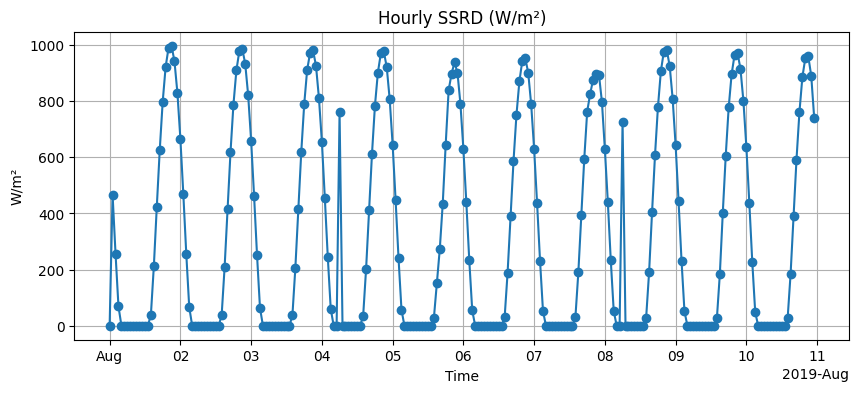

In [8]:
# Pick a single grid point
ssrd_point = ssrd_hr_W.sel(latitude=36, longitude=-120, method="nearest")  

# Look at the first 2 days, check that it's now de-accumulated
values = ssrd_point.sel(valid_time=slice("2019-08-01T00","2019-08-02T23")).values
print(values)

# min and max values for these two days
print("\n", min(values), max(values))

ssrd_days = ssrd_point.sel(valid_time=slice("2019-08-01T00","2019-08-10T23"))

# Plot
import matplotlib.pyplot as plt
ssrd_days.plot(marker='o', figsize=(10,4))
plt.title("Hourly SSRD (W/m²)")
plt.ylabel("W/m²")
plt.xlabel("Time")
plt.grid(True)
plt.show()

### calculate fdir_frac -- simple fraction, use ssrd_hr_W as denominator

In [9]:
# check that numerator and denomiator are of the same units
print(fdir_W.attrs["units"])
print(ssrd_hr_W.attrs["units"])

W m**-2
W m**-2


In [19]:
fdir_frac = xr.where(ssrd_hr_W.isnull(), np.nan, 
                xr.where(ssrd_hr_W > 0, fdir_W.values / ssrd_hr_W.where(ssrd_hr_W > 0), 0.0))
fdir_frac.attrs["long_name"] = "fraction of surface solar radiation that is direct (0-1)"
fdir_frac.attrs["units"] = ""  # no units since it's a fraction

# set all values that are greater than 1 to be 1
fdir_frac = fdir_frac.clip(max=1)

# summary of fdir_frac values
fdir_frac.to_series().describe()

count    5.532799e+06
mean     4.529620e-01
std      3.986006e-01
min      0.000000e+00
25%      0.000000e+00
50%      6.089712e-01
75%      8.565223e-01
max      1.000000e+00
Name: ssrd, dtype: float64

### put ssrd_hr_W, fdir_frac and fdir_W into the working dataset of WBGT input variables

In [22]:
# view wbgt_inputs_aug_2019.nc before adding variables
wbgt_inputs_aug_2019 = xr.open_dataset('wbgt_inputs_aug_2019.nc') # open ERA5-Land NetCDF file
print(wbgt_inputs_aug_2019) # view structure

<xarray.Dataset> Size: 240MB
Dimensions:     (valid_time: 744, latitude: 96, longitude: 105)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 2019-08-01 ... 2019-08-31T23:...
  * latitude    (latitude) float64 768B 42.0 41.9 41.8 41.7 ... 32.7 32.6 32.5
  * longitude   (longitude) float64 840B -124.5 -124.4 -124.3 ... -114.2 -114.1
    number      int64 8B ...
    expver      (valid_time) <U4 12kB ...
    year        (valid_time) int64 6kB ...
    month       (valid_time) int64 6kB ...
    day         (valid_time) int64 6kB ...
    hour        (valid_time) int64 6kB ...
    dday        (valid_time) float64 6kB ...
Data variables:
    solar       (valid_time, latitude, longitude) float32 30MB ...
    fdir        (valid_time, latitude, longitude) float32 30MB ...
    pres        (valid_time, latitude, longitude) float32 30MB ...
    Tair        (valid_time, latitude, longitude) float32 30MB ...
    relhum      (valid_time, latitude, longitude) float32 30MB ...
    speed      

In [23]:
# remove old fdir
wbgt_inputs_aug_2019 = wbgt_inputs_aug_2019.drop_vars('fdir')

In [25]:
# add fdir_frac, fdir_W, ssrd_hr_W
wbgt_inputs_aug_2019['fdir_frac'] = fdir_frac
wbgt_inputs_aug_2019['fdir_W'] = fdir_W
wbgt_inputs_aug_2019['ssrd_hr_W'] = ssrd_hr_W  # de-accumulated ssrd

### clip to CA shape

In [26]:
ca = gpd.read_file("urban 2019/ca_state/CA_state.shp")
ca = ca.to_crs("EPSG:4326")
mask = regionmask.mask_geopandas(ca, wbgt_inputs_aug_2019.longitude, wbgt_inputs_aug_2019.latitude)
wbgt_inputs_aug_2019 = wbgt_inputs_aug_2019.where(~mask.isnull()) # keep whole grid cells

In [27]:
wbgt_inputs_aug_2019_new = wbgt_inputs_aug_2019
print(wbgt_inputs_aug_2019_new)

<xarray.Dataset> Size: 300MB
Dimensions:     (valid_time: 744, latitude: 96, longitude: 105)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 2019-08-01 ... 2019-08-31T23:...
  * latitude    (latitude) float64 768B 42.0 41.9 41.8 41.7 ... 32.7 32.6 32.5
  * longitude   (longitude) float64 840B -124.5 -124.4 -124.3 ... -114.2 -114.1
    number      int64 8B 0
    expver      (valid_time) <U4 12kB ...
    year        (valid_time) int64 6kB ...
    month       (valid_time) int64 6kB ...
    day         (valid_time) int64 6kB ...
    hour        (valid_time) int64 6kB ...
    dday        (valid_time) float64 6kB ...
Data variables:
    solar       (valid_time, latitude, longitude) float32 30MB nan nan ... nan
    pres        (valid_time, latitude, longitude) float32 30MB nan nan ... nan
    Tair        (valid_time, latitude, longitude) float32 30MB nan nan ... nan
    relhum      (valid_time, latitude, longitude) float32 30MB nan nan ... nan
    speed       (valid_time, latitud

### export wbgt_inputs_aug_2019_new.nc as a file

In [29]:
# export wbgt_inputs_aug_2019 as a netCDF file
# wbgt_inputs_aug_2019_new.to_netcdf("wbgt_inputs_aug_2019_new.nc")

count    3.093704e+06
mean     4.531837e-01
std      3.981048e-01
min      0.000000e+00
25%      0.000000e+00
50%      6.054213e-01
75%      8.566125e-01
max      1.000000e+00
Name: fdir_frac, dtype: float64

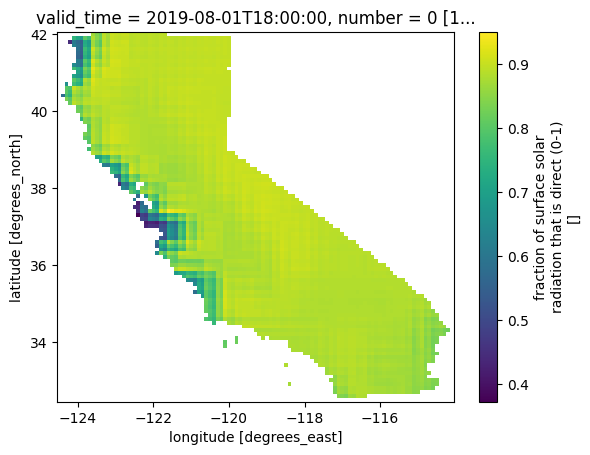

In [30]:
wbgt_inputs_aug_2019_new["fdir_frac"].sel(valid_time="2019-08-01T18:00").plot()
wbgt_inputs_aug_2019_new["fdir_frac"].to_series().describe()  # check that values are between 0 and 1